# Phase A — DSP-Bausteine & Copy-Up (Demo)

Schlanke Veranschaulichung der DSP-Kette aus dem `bwe`-Paket. Das Notebook ist
**nicht self-contained** — es importiert die getesteten Bausteine aus `bwe/` und
zeigt nur, *was passiert*: STFT-Round-Trip, Bandbegrenzung und Copy-Up an einem
Beispiel-Track.

Voraussetzung: `scripts/prepare_sample.py` wurde ausgeführt (32-kHz-Cache).

In [1]:
import os
# MÜSSEN vor dem TensorFlow-Import gesetzt sein (oneDNN-Crash-Fix + leise Logs).
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
import tensorflow as tf

from bwe import config as cfg
from bwe.dsp.stft import stft, istft, drop_nyquist
from bwe.dsp.compress import compress
from bwe.dsp.bandlimit import bandlimit
from bwe.dsp.copyup import copy_up_hf
from bwe.data import splits as SP

print(cfg.summary())

SR=32000 Hz | N_FFT=1024 HOP=256 | 31.250 Hz/Bin
Bins: full=513 net=512 | Cutoff=8000 Hz -> Bin 256
Copy-Up-Quellband 4000-8000 Hz = Bins 128..256
Segment: 128 Frames = 33536 Samples (~1.048 s)
DATA_ROOT=C:\Users\danyr\bwe_data\musdb18hq_32k


In [2]:
def load_demo(split="train", index=0, seconds=5.0, offset=10.0):
    """Mono-Mix-Ausschnitt eines Tracks (Summe der Stems, normiert)."""
    track = SP.get_split(split)[index]
    n, start = int(seconds * cfg.SR), int(offset * cfg.SR)
    mix = None
    for s in cfg.STEMS:
        d, _ = sf.read(str(track.stems[s]), start=start, frames=n,
                       always_2d=True, dtype="float32")
        m = d.mean(axis=1)
        mix = m if mix is None else mix + m
    mix /= max(1e-9, np.max(np.abs(mix)))
    return track.name, mix.astype(np.float32)


def db(spec):
    return 20.0 * np.log10(np.abs(spec) + 1e-6)


def show_spec(ax, spec, title, vmin=-80, vmax=20):
    S = db(spec)
    im = ax.imshow(S, origin="lower", aspect="auto", vmin=vmin, vmax=vmax,
                   extent=[0, S.shape[1], 0, cfg.SR / 2 / 1000])
    ax.axhline(cfg.CUTOFF_HZ / 1000, color="w", lw=0.8, ls="--")
    ax.set_title(title); ax.set_xlabel("Frame"); ax.set_ylabel("kHz")
    return im


name, wave = load_demo()
print(f"Demo-Track: {name}  |  {len(wave) / cfg.SR:.1f} s")

Demo-Track: A Classic Education - NightOwl  |  5.0 s


## 1. STFT-Round-Trip

`istft(stft(x)) ≈ x` — der Fehler ist im Inneren winzig (Randframes ausgenommen).

max |Fehler| im Inneren: 2.3841858e-07


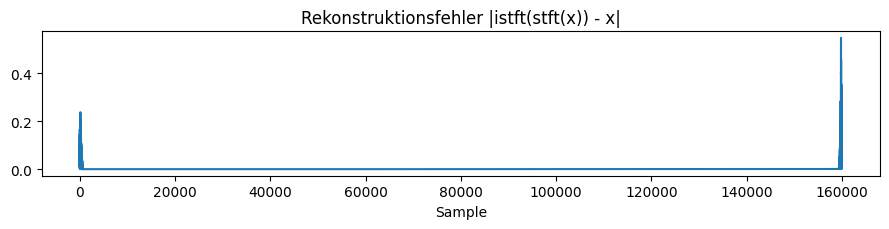

In [3]:
spec = stft(wave)
recon = istft(spec).numpy()
err = np.abs(recon[:len(wave)] - wave)
print("max |Fehler| im Inneren:", err[cfg.N_FFT:-cfg.N_FFT].max())

plt.figure(figsize=(9, 2.4))
plt.plot(err)
plt.title("Rekonstruktionsfehler |istft(stft(x)) - x|")
plt.xlabel("Sample"); plt.tight_layout(); plt.show()

## 2. Bandbegrenzung @ 8 kHz

Der Input entsteht durch Nullsetzen aller Bins ab dem Cutoff (Bin 256) — das HF-Band oberhalb der weißen Linie verschwindet.

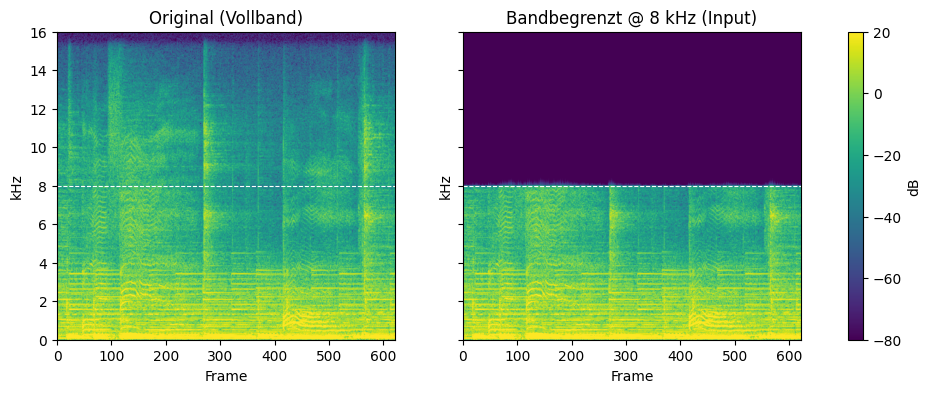

In [4]:
band = bandlimit(wave)
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
show_spec(ax[0], stft(wave), "Original (Vollband)")
im = show_spec(ax[1], stft(band), "Bandbegrenzt @ 8 kHz (Input)")
fig.colorbar(im, ax=ax, label="dB"); plt.show()

## 3. Copy-Up (HF-Initialisierung)

Auf dem **komprimierten** Input-Spektrogramm wird das Band 4–8 kHz zweimal nach
oben gekachelt (→ 8–12 und 12–16 kHz) und am Crossover grob im Pegel angeglichen.
Das HF ist danach gefüllt, aber sichtbar „kopiert" (wiederholte Struktur) — die
bewusst primitive Baseline.

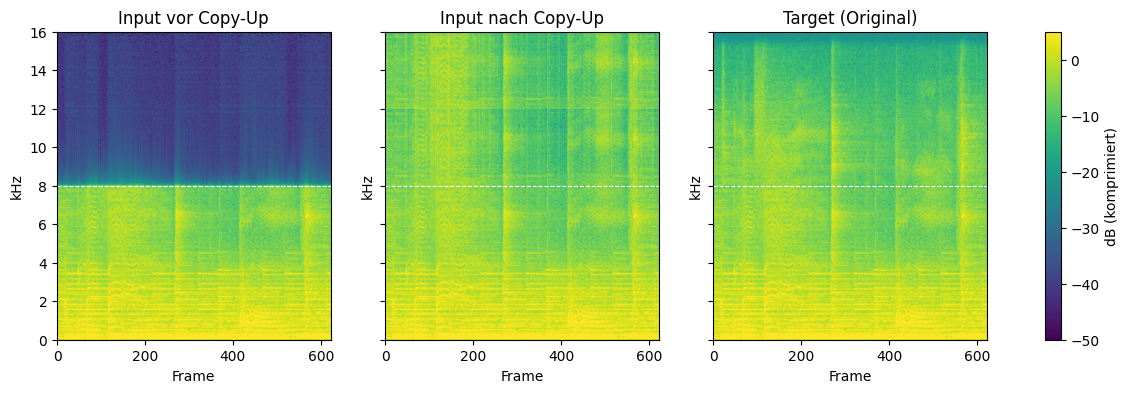

In [5]:
spec_band = drop_nyquist(compress(stft(band)))   # komprimiert, 512 Bins
spec_in = copy_up_hf(spec_band)                   # HF per Hochkopie gefüllt
spec_tg = drop_nyquist(compress(stft(wave)))      # Target (Original)

fig, ax = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
show_spec(ax[0], spec_band, "Input vor Copy-Up", vmin=-50, vmax=5)
show_spec(ax[1], spec_in, "Input nach Copy-Up", vmin=-50, vmax=5)
im = show_spec(ax[2], spec_tg, "Target (Original)", vmin=-50, vmax=5)
fig.colorbar(im, ax=ax, label="dB (komprimiert)"); plt.show()

### Crossover-Zoom

Detail um den Cutoff (8 kHz): die „Naht", an der das kopierte HF ansetzt.

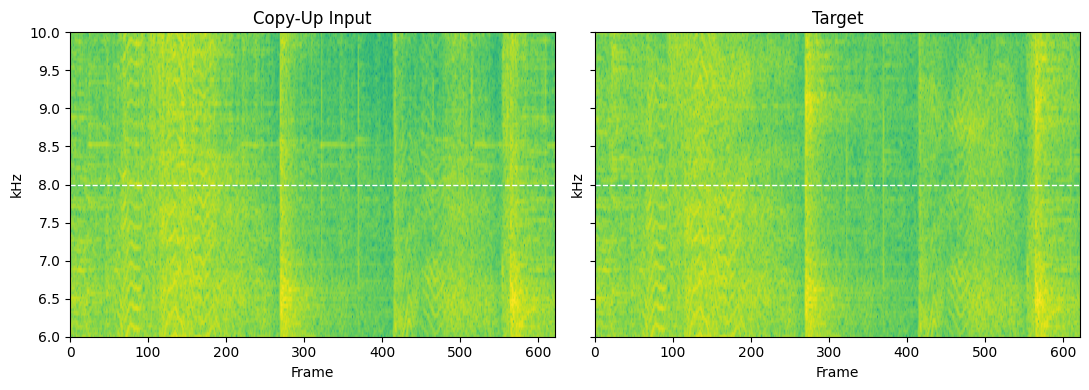

In [ ]:
lo, hi = cfg.CUTOFF_BIN - 64, cfg.CUTOFF_BIN + 64
fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for a, S, ttl in zip(ax, [spec_in, spec_tg], ["Copy-Up Input", "Target"]):
    a.imshow(db(S)[lo:hi], origin="lower", aspect="auto", vmin=-50, vmax=5,
             extent=[0, S.shape[1], lo * cfg.FREQ_RES / 1000, hi * cfg.FREQ_RES / 1000])
    a.axhline(cfg.CUTOFF_HZ / 1000, color="w", lw=1, ls="--")
    a.set_title(ttl); a.set_xlabel("Frame"); a.set_ylabel("kHz")
plt.tight_layout(); plt.show()

## Fazit

Die DSP-Kette steht und ist getestet (STFT-Round-Trip, Kompression, Bandbegrenzung,
Copy-Up, tf.data-Pipeline). Copy-Up füllt das HF sichtbar, aber als grobe Hochkopie —
das ist der **naive Anker**. Sein Kontrast macht später die gelernten Stufen
(komplexe Regression → GAN) sichtbar: von „kopiert/verwaschen" zu „scharf".